# Handover Project: Statistical Analysis

This notebook performs statistical analysis on the aggregated metrics from the handover project experiments. It focuses on within-subjects comparisons across different report generation conditions.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
import os

# Settings
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

# Path to the aggregated metrics
CSV_PATH = "/media/kaleb/T7/handover_project/participant_data/analysis/metrics_output/aggregated_metrics.csv"

if not os.path.exists(CSV_PATH):
    print(f"Warning: {CSV_PATH} not found. Please check the path.")

## 1. Load and Prepare Data

In [4]:
df = pd.read_csv(CSV_PATH)
df = df[df["model"] == "gpt"]


# get derived metric (communcative compression)
df["communicative_compression"] = df["iac_cost_saved"].div(df["token_count"])

# rename conditions
condition_mapping = {
    "user_report": "user-only",
    "full_realization": "FR",
    "task_aware": "TA",
    "task_aware_raw_ablation": "end2end",
    "no_report_task_aware": "TA -user"
}

df.replace(condition_mapping, inplace=True)

# Ensure consistent conditions
conditions = condition_mapping.values()
df = df[df["condition"].isin(conditions)]

# Pivot the data to wide format for within-subjects analysis
df_wide = df.pivot(index='participant_id', columns='condition')

print(f"Loaded metrics for {len(df_wide)} participants.")
df_wide.head()

Loaded metrics for 13 participants.


model                                 token_count       \
condition         FR   TA TA -user end2end user-only          FR   TA   
participant_id                                                          
501              gpt  gpt      gpt     gpt       gpt         331  203   
502              gpt  gpt      gpt     gpt       gpt         274  184   
503              gpt  gpt      gpt     gpt       gpt         307  211   
504              gpt  gpt      gpt     gpt       gpt         341  220   
505              gpt  gpt      gpt     gpt       gpt         334  171   

                                           ... iac_resource_savings          \
condition      TA -user end2end user-only  ...                   FR      TA   
participant_id                             ...                                
501                 190     284       157  ...               170.17  211.67   
502                 167     230        70  ...               207.50  207.50   
503                 149     233       131  ...               174.34  174.34   
504                 156     273        97  ...               220.01  137.01   
505                 171     225       247  ...               215.84  215.84   

                                            communicative_compression  \
condition      TA -user end2end   user-only                        FR   
participant_id                                                          
501              170.17   87.17  181.223333                  1.770906   
502              207.50  207.50  207.500000                  1.971898   
503              174.34  174.34  154.946667                  1.478632   
504              137.01  137.01    0.000000                  1.953109   
505              215.84  215.84   30.446667                  1.642635   

                                                        
condition             TA  TA -user   end2end user-only  
participant_id                                          
501             3.091970  3.085105  1.771725  1.779766  
502             2.936413  3.235329  2.414348  2.964286  
503             2.151374  2.845235  2.305322  2.275929  
504             2.513682  3.544936  2.355348  0.000000  
505             3.208421  3.208421  2.438400  1.713549  

[5 rows x 100 columns]

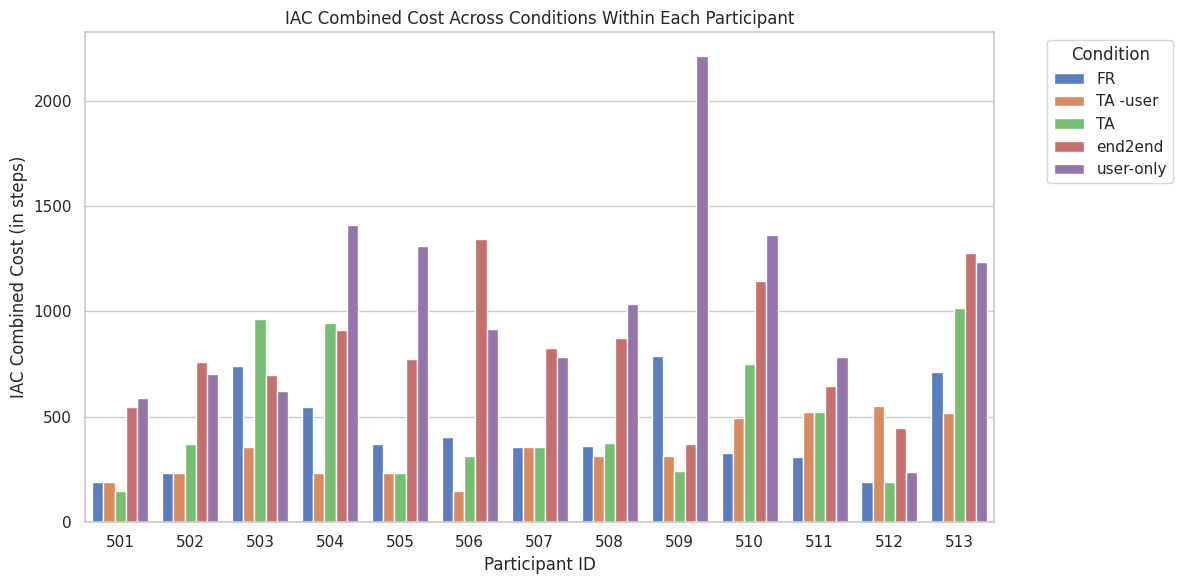

In [5]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='participant_id', y='iac_combined_cost', hue='condition')
plt.title('IAC Combined Cost Across Conditions Within Each Participant')
plt.ylabel('IAC Combined Cost (in steps)')
plt.xlabel('Participant ID')
plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [6]:
# Sourced alpha from CostConfig in src/pipelines/evaluation/costs.py
import sys
import os
if os.path.abspath("..") not in sys.path:
    sys.path.append(os.path.abspath(".."))
from src.pipelines.evaluation.costs import CostConfig

cost_config = CostConfig()
alpha = cost_config.misinformation_multiplier

# Calculate percentage shares of omission and misinformation costs as contributors to combined cost
df["omission_share_pct"] = (df["iac_omission_cost"] / df["iac_combined_cost"] * 100).fillna(0)
df["misinformation_share_pct"] = ((alpha * df["iac_misinformation_cost"]) / df["iac_combined_cost"] * 100).fillna(0)

conditions_order = ["user-only", "FR", "TA", "end2end", "TA -user"]

iac_summary_data = []
for cond in conditions_order:
    cond_df = df[df["condition"] == cond]
    
    # Combined cost stats
    med_combined = cond_df["iac_combined_cost"].median()
    min_combined = cond_df["iac_combined_cost"].min()
    max_combined = cond_df["iac_combined_cost"].max()
    
    # Omission share stats
    med_omission = cond_df["omission_share_pct"].median()
    min_omission = cond_df["omission_share_pct"].min()
    max_omission = cond_df["omission_share_pct"].max()
    
    # Misinformation share stats
    med_misinfo = cond_df["misinformation_share_pct"].median()
    min_misinfo = cond_df["misinformation_share_pct"].min()
    max_misinfo = cond_df["misinformation_share_pct"].max()
    
    iac_summary_data.append({
        "Condition": cond,
        "Median Combined Cost": round(med_combined, 2),
        "Range Combined Cost": f"[{min_combined:.2f}, {max_combined:.2f}]",
        "Median Omission Share (%)": f"{med_omission:.1f}%",
        "Range Omission Share (%)": f"[{min_omission:.1f}%, {max_omission:.1f}%]",
        "Median Misinformation Share (%)": f"{med_misinfo:.1f}%",
        "Range Misinformation Share (%)": f"[{min_misinfo:.1f}%, {max_misinfo:.1f}%]"
    })

df_iac_summary = pd.DataFrame(iac_summary_data)
print(f"Misinformation multiplier (alpha) used in calculations: {alpha}")
print("\nInformation Access Cost (IAC) Summary Table:")
display(df_iac_summary)

Misinformation multiplier (alpha) used in calculations: 3.0

Information Access Cost (IAC) Summary Table:


,Condition,Median Combined Cost,Range Combined Cost,Median Omission Share (%),Range Omission Share (%),Median Misinformation Share (%),Range Misinformation Share (%)
0,user-only,916.98,"[237.50, 2213.19]",70.6%,"[27.4%, 100.0%]",29.4%,"[0.0%, 72.6%]"
1,FR,361.20,"[191.50, 789.24]",44.6%,"[18.2%, 100.0%]",55.4%,"[0.0%, 81.8%]"
2,TA,370.21,"[150.00, 1017.60]",63.0%,"[16.0%, 100.0%]",37.0%,"[0.0%, 84.0%]"
3,end2end,773.20,"[370.21, 1345.51]",32.5%,"[14.2%, 50.4%]",67.5%,"[49.6%, 85.8%]"
4,TA -user,316.20,"[150.00, 551.50]",100.0%,"[27.3%, 100.0%]",0.0%,"[0.0%, 72.7%]"


## 2. Statistical Helper Functions

We use non-parametric tests as the sample size is small and we cannot assume normality.
- **Wilcoxon Signed-Rank Test**: For 2-group within-subjects comparisons.
- **Friedman Test**: For 3+ group within-subjects comparisons.
- **Kendall's W**: Effect size for Friedman test.
- **Rank-Biserial Correlation (r)**: Effect size for Wilcoxon test.

In [7]:
def calculate_kendall_w(friedman_stat, n, k):
    """Calculates Kendall's W for Friedman test."""
    return friedman_stat / (n * (k - 1))

def calculate_rank_biserial(wilcoxon_stat, n):
    """Calculates Rank-Biserial Correlation (r) for Wilcoxon test."""
    # r = 1 - (2 * W / (n * (n + 1)))
    # Or more robustly via Z: r = Z / sqrt(N)
    # Scipy doesn't return Z directly, but we can approximate or use the formula below
    # Using a simpler r = Z / sqrt(n) approach if we had Z, 
    # but for Wilcoxon, common r = 1 - (4 * W / (n * (n + 1)))
    # Here we'll use a simplified version: r = 1 - (2 * W / total_rank_sum)
    total_ranks = n * (n + 1) / 2
    return 1 - (2 * wilcoxon_stat / total_ranks)

def annotate_stats(ax, p_value, x1, x2, y, h):
    """Adds significance markers to a plot."""
    if p_value < 0.001:
        sig = "***"
    elif p_value < 0.01:
        sig = "**"
    elif p_value < 0.05:
        sig = "*"
    else:
        sig = "n.s."
    
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c='k')
    ax.text((x1+x2)*.5, y+h, sig, ha='center', va='bottom', color='k', fontsize=12)



## 3. Analysis: Precision, Recall, and F1

Comparison across all conditions. We start with a Friedman test across all conditions and perform post-hoc Wilcoxon follow-up comparisons.

In [8]:
metrics_pr = ['precision', 'recall', 'f1']
results_pr = []
posthoc_pr_results = []

pairs = [
    ("user-only", "TA"),
    ("FR", "TA"),
    ("TA", "end2end"),
    ("TA", "TA -user")
]

for metric in metrics_pr:
    data = [df_wide[metric][c] for c in conditions]

    # Remove participants with any NaNs in these columns
    mask = ~(data[0].isna() | data[1].isna() | data[2].isna())
    data = [d[mask] for d in data]
    if len(data[0]) < 2:
        continue
        
    stat, p = stats.friedmanchisquare(*data)
    w = calculate_kendall_w(stat, len(data[0]), len(conditions))
    
    results_pr.append({
        'Metric': metric,
        'Friedman Stat': stat,
        'p-value': p,
        'Kendall\'s W': w
    })
    
    # Post-hoc if significant
    if p < 0.05:
        p_vals = []
        medians = []
        w_stats = []
        r_vals = []
        for p1, p2 in pairs:
            pair_mask = ~(df_wide[metric][p1].isna() | df_wide[metric][p2].isna())
            w_stat, pp = stats.wilcoxon(df_wide[metric][p1][pair_mask], df_wide[metric][p2][pair_mask])
            p_vals.append(pp)
            medians.append((df_wide[metric][p1][pair_mask].median(), df_wide[metric][p2][pair_mask].median()))
            w_stats.append(w_stat)
            r_val = calculate_rank_biserial(w_stat, pair_mask.sum())
            r_vals.append(r_val)
        
        # Holm correction
        _, p_adj, _, _ = multipletests(p_vals, method='holm')
        
        for i, pair in enumerate(pairs):
            posthoc_pr_results.append({
                'Metric': metric,
                'Comparison': f"{pair[0]} vs {pair[1]}",
                'Median 1': medians[i][0],
                'Median 2': medians[i][1],
                'Wilcoxon W': w_stats[i],
                'p-adj': p_adj[i],
                'Effect Size (r)': r_vals[i]
            })

results_pr_df = pd.DataFrame(results_pr)
posthoc_pr_df = pd.DataFrame(posthoc_pr_results)

print("Precision / Recall / F1 Statistical Results (Friedman Test):")
display(results_pr_df)
if not posthoc_pr_df.empty:
    print("\nPost-hoc Wilcoxon (Holm-corrected):")
    display(posthoc_pr_df)

Precision / Recall / F1 Statistical Results (Friedman Test):


,Metric,Friedman Stat,p-value,Kendall's W
0,precision,46.841270,1.645525e-09,0.900794
1,recall,41.065637,2.605020e-08,0.789724
2,f1,42.239382,1.488037e-08,0.812296



Post-hoc Wilcoxon (Holm-corrected):


,Metric,Comparison,Median 1,Median 2,Wilcoxon W,p-adj,Effect Size (r)
0,precision,user-only vs TA,0.000000,1.000000,0.0,0.000977,1.000000
1,precision,FR vs TA,0.787879,1.000000,1.0,0.000977,0.978022
2,precision,TA vs end2end,1.000000,0.700000,0.0,0.000977,1.000000
3,precision,TA vs TA -user,1.000000,1.000000,3.0,0.156250,0.934066
4,recall,user-only vs TA,0.000000,0.615385,0.0,0.000977,1.000000
5,recall,FR vs TA,0.675000,0.615385,9.0,0.016113,0.802198
6,recall,TA vs end2end,0.615385,0.463415,4.0,0.005127,0.912088
7,recall,TA vs TA -user,0.615385,0.625000,38.0,0.969727,0.164835
8,f1,user-only vs TA,0.000000,0.754717,0.0,0.000977,1.000000
9,f1,FR vs TA,0.741935,0.754717,32.0,0.751465,0.296703


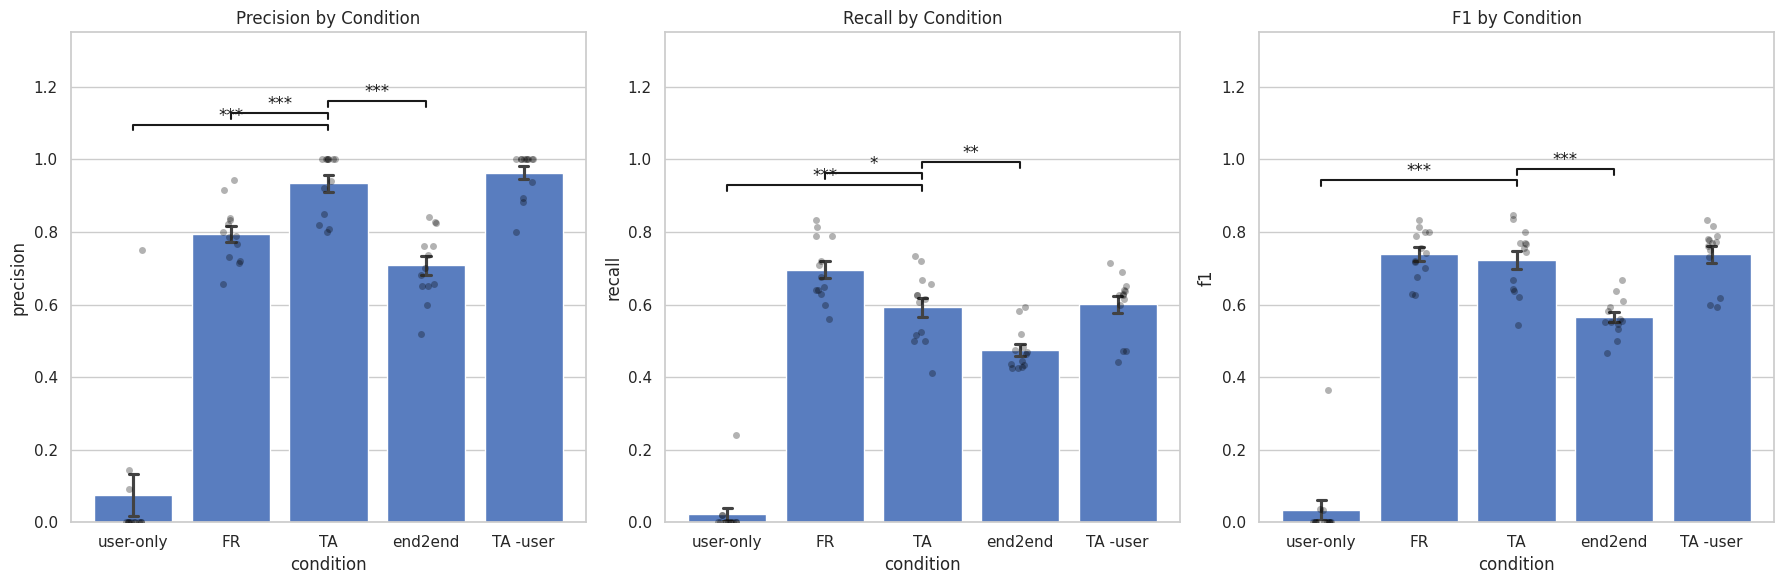

In [9]:
# Visualization for P/R/F1
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plot_df = df
conditions_list = list(conditions)

for i, metric in enumerate(metrics_pr):
    sns.barplot(data=plot_df, x='condition', y=metric, ax=axes[i], capsize=.1, errorbar='se', order=conditions_list)
    sns.stripplot(data=plot_df, x='condition', y=metric, ax=axes[i], color='black', alpha=0.3, order=conditions_list)
    
    axes[i].set_title(f"{metric.capitalize()} by Condition")
    axes[i].set_ylim(0, 1.35)
    
    # Add post-hoc significance markers if available
    metric_posthoc = posthoc_pr_df[posthoc_pr_df['Metric'] == metric]
    if not metric_posthoc.empty:
        max_y = df[metric].max()
        y_offset = 0.08
        curr_y = max_y + y_offset
        
        idx_map = {c: idx for idx, c in enumerate(conditions_list)}
        
        for _, row in metric_posthoc.iterrows():
            p_adj = row['p-adj']
            p1_name, p2_name = row['Comparison'].split(' vs ')
            if p_adj < 0.05:
                annotate_stats(axes[i], p_adj, idx_map[p1_name], idx_map[p2_name], curr_y, y_offset*0.2)
                curr_y += y_offset * 0.4

plt.tight_layout()
plt.show()

## 4. Analysis: IAC and Costs

Comparison across `full_realization`, `task_aware`, and `user_report`.

In [10]:
from itertools import combinations

metrics_iac = ['iac_combined_cost', 'iac_misinformation_cost', 'iac_cost_saved', "communicative_compression"]
results_iac = []
posthoc_results = []

pairs = [
    ("user-only", "TA"),
    ("FR", "TA"),
    ("TA", "end2end"),
    ("TA", "TA -user")
]


for metric in metrics_iac:
    data = [df_wide[metric][c] for c in conditions]

    # Remove participants with any NaNs in these columns
    mask = ~(data[0].isna() | data[1].isna() | data[2].isna())
    data = [d[mask] for d in data]
    if len(data[0]) < 2:
        continue
        
    stat, p = stats.friedmanchisquare(*data)
    w = calculate_kendall_w(stat, len(data[0]), len(conditions))
    
    results_iac.append({
        'Metric': metric,
        'Friedman Stat': stat,
        'p-value': p,
        'Kendall\'s W': w
    })
    
    # Post-hoc if significant
    if p < 0.05:
        p_vals = []
        medians = []
        w_stats = []
        r_vals = []
        for p1, p2 in pairs:
            pair_mask = ~(df_wide[metric][p1].isna() | df_wide[metric][p2].isna())
            w_stat, pp = stats.wilcoxon(df_wide[metric][p1][pair_mask], df_wide[metric][p2][pair_mask])
            p_vals.append(pp)
            medians.append((df_wide[metric][p1][pair_mask].median(), df_wide[metric][p2][pair_mask].median()))
            w_stats.append(w_stat)
            r_val = calculate_rank_biserial(w_stat, pair_mask.sum())
            r_vals.append(r_val)
        
        # Holm correction
        _, p_adj, _, _ = multipletests(p_vals, method='holm')
        
        for i, pair in enumerate(pairs):
            posthoc_results.append({
                'Metric': metric,
                'Comparison': f"{pair[0]} vs {pair[1]}",
                'Median 1': medians[i][0],
                'Median 2': medians[i][1],
                'Wilcoxon W': w_stats[i],
                'p-adj': p_adj[i],
                'Effect Size (r)': r_vals[i]
            })

results_iac_df = pd.DataFrame(results_iac)
posthoc_df = pd.DataFrame(posthoc_results)

print("IAC / Cost Statistical Results (Friedman Test):")
display(results_iac_df)
if not posthoc_df.empty:
    print("\nPost-hoc Wilcoxon (Holm-corrected):")
    display(posthoc_df)

IAC / Cost Statistical Results (Friedman Test):


,Metric,Friedman Stat,p-value,Kendall's W
0,iac_combined_cost,26.852590,2.129066e-05,0.516396
1,iac_misinformation_cost,24.902128,5.264151e-05,0.478887
2,iac_cost_saved,33.852814,7.988185e-07,0.651016
3,communicative_compression,31.193798,2.794986e-06,0.599881



Post-hoc Wilcoxon (Holm-corrected):


,Metric,Comparison,Median 1,Median 2,Wilcoxon W,p-adj,Effect Size (r)
0,iac_combined_cost,user-only vs TA,916.980000,370.210000,5.0,0.009766,0.890110
1,iac_combined_cost,FR vs TA,361.200000,370.210000,20.5,0.287109,0.549451
2,iac_combined_cost,TA vs end2end,370.210000,773.200000,7.0,0.013916,0.846154
3,iac_combined_cost,TA vs TA -user,370.210000,316.200000,11.0,0.210938,0.758242
4,iac_misinformation_cost,user-only vs TA,90.000000,45.670000,20.0,0.523438,0.560440
5,iac_misinformation_cost,FR vs TA,60.000000,45.670000,12.5,0.523438,0.725275
6,iac_misinformation_cost,TA vs end2end,45.670000,180.000000,4.0,0.006836,0.912088
7,iac_misinformation_cost,TA vs TA -user,45.670000,0.000000,5.0,0.234375,0.890110
8,iac_cost_saved,user-only vs TA,143.200000,548.640000,0.0,0.000977,1.000000
9,iac_cost_saved,FR vs TA,548.640000,548.640000,5.5,0.687500,0.879121


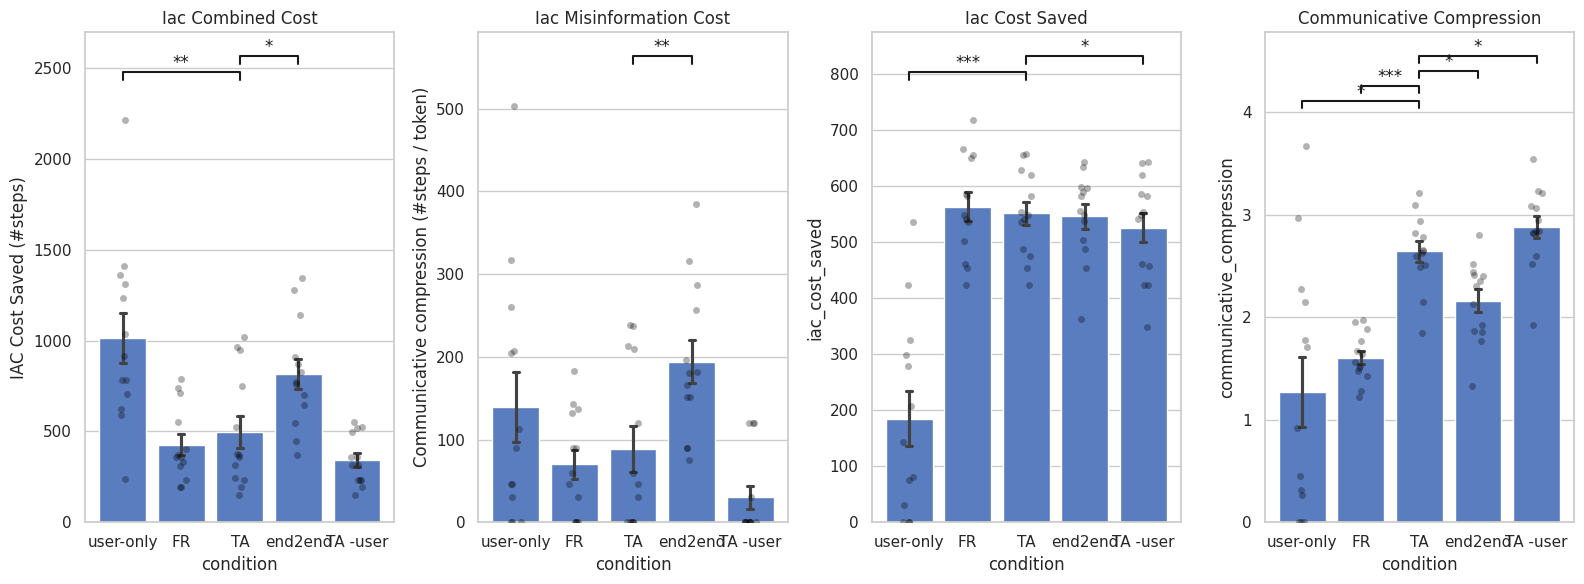

In [11]:
# Visualization for IAC Metrics
fig, axes = plt.subplots(1, len(metrics_iac), figsize=(16, 6))
if len(metrics_iac) == 1: axes = [axes]

# Create a 'raw' condition dataframe to include in the plot
# raw_df = df.drop_duplicates(subset=['participant_id']).copy()
# raw_df['condition'] = 'raw'
# for m in metrics_iac:
#     if f'raw_{m}' in raw_df.columns:
#         raw_df[m] = raw_df[f'raw_{m}']
# plot_df = pd.concat([df[df['condition'].isin(['user_report', 'task_aware', 'full_realization'])], raw_df], ignore_index=True)
plot_df = df


for i, metric in enumerate(metrics_iac):
    sns.barplot(data=plot_df, x='condition', y=metric, ax=axes[i], capsize=.1, errorbar='se', 
                order=conditions)
    sns.stripplot(data=plot_df, x='condition', y=metric, ax=axes[i], color='black', alpha=0.3,
                  order=conditions)
    
    axes[i].set_title(f"{metric.replace('_', ' ').title()}")
    
    # Add post-hoc significance markers if available
    metric_posthoc = posthoc_df[posthoc_df['Metric'] == metric]
    if not metric_posthoc.empty:
        max_y = df[metric].max()
        # Simple logic for annotations (can be refined)
        y_offset = max_y * 0.1
        curr_y = max_y + y_offset
        
        # Mapping condition names to plot indices (order: raw, user_report, task_aware, full_realization)
        idx_map = {c: idx for idx, c in enumerate(conditions)}
        
        for _, row in metric_posthoc.iterrows():
            p_adj = row['p-adj']
            p1_name, p2_name = row['Comparison'].split(' vs ')
            if p_adj < 0.05:
                annotate_stats(axes[i], p_adj, idx_map[p1_name], idx_map[p2_name], curr_y, y_offset*0.2)
                curr_y += y_offset * 0.4

axes[0].set_ylabel("IAC Cost Saved (#steps)")
axes[1].set_ylabel("Communicative compression (#steps / token)")

plt.tight_layout()
plt.show()

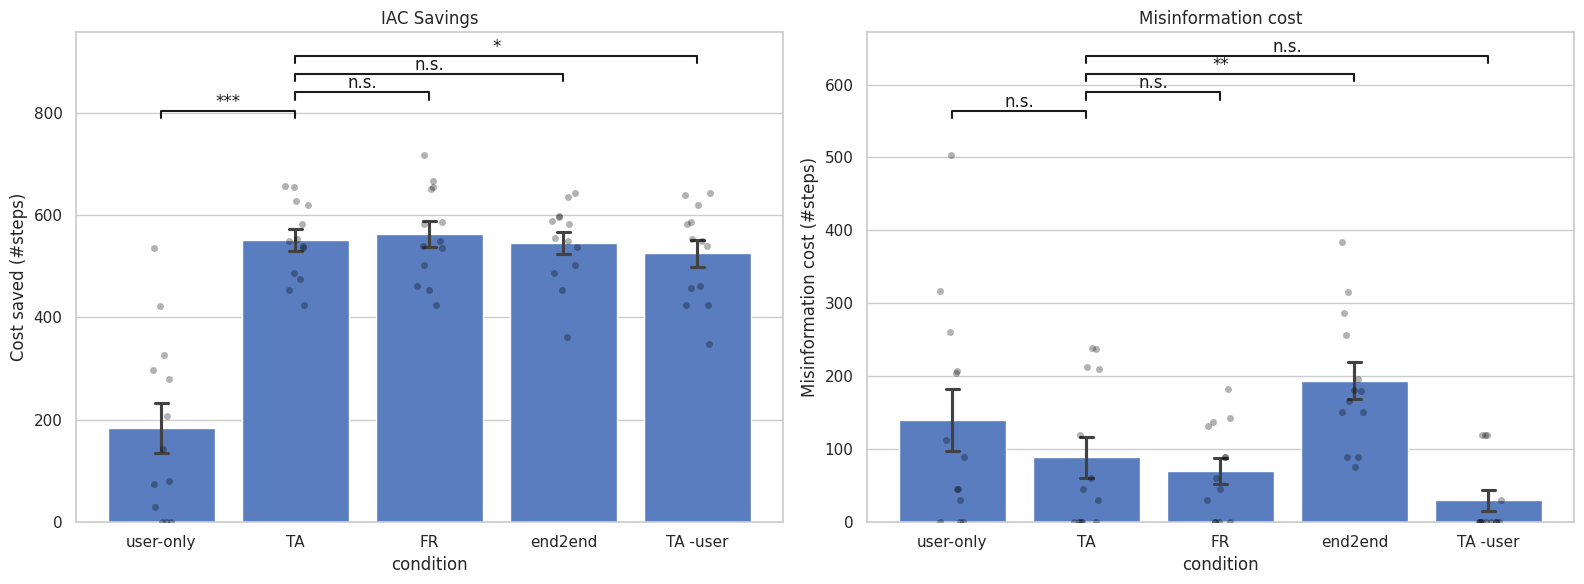

In [12]:
# Create separate figures for pub
conditions_to_plot = ["user-only", "TA", "FR", "end2end", "TA -user"]
plot_df = df[df['condition'].isin(conditions_to_plot)]
metrics_to_plot = ["iac_cost_saved", "iac_misinformation_cost"]
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(16, 6))
if len(metrics_to_plot) == 1: axes = [axes]

for i, metric in enumerate(metrics_to_plot):
    sns.barplot(data=plot_df, x='condition', y=metric, ax=axes[i], capsize=.1, errorbar='se', 
                order=conditions_to_plot)
    sns.stripplot(data=plot_df, x='condition', y=metric, ax=axes[i], color='black', alpha=0.3,
                  order=conditions_to_plot)
    
    axes[i].set_title(f"{metric.replace('_', ' ').title()}")
    
    # Add post-hoc significance markers if available
    metric_posthoc = posthoc_df[posthoc_df['Metric'] == metric]
    if (metric != "iac_combined_cost") and not metric_posthoc.empty:
        max_y = df[metric].max()
        # Simple logic for annotations (can be refined)
        y_offset = max_y * 0.1
        curr_y = max_y + y_offset
        
        # Mapping condition names to plot indices
        idx_map = {c: idx for idx, c in enumerate(conditions_to_plot)}
        
        for _, row in metric_posthoc.iterrows():
            p_adj = row['p-adj']
            p1_name, p2_name = row['Comparison'].split(' vs ')
            # if p_adj < 0.05:
            if p1_name in conditions_to_plot and p2_name in conditions_to_plot:
                annotate_stats(axes[i], p_adj, idx_map[p1_name], idx_map[p2_name], curr_y, y_offset*0.2)
                curr_y += y_offset * 0.5


axes[0].set_ylabel("Cost saved (#steps)")
axes[0].set_title("IAC Savings")

axes[1].set_ylabel("Misinformation cost (#steps)")
axes[1].set_title("Misinformation cost")

plt.tight_layout()
plt.show()

In [13]:
def annotate_stats_inverted(ax, p_value, x1, x2, y, h):
    """Adds significance markers to a plot."""
    if p_value < 0.001:
        sig = "***"
    elif p_value < 0.01:
        sig = "**"
    elif p_value < 0.05:
        sig = "*"
    else:
        # return
        sig = "n.s."
    
    ax.plot([x1, x1, x2, x2], [y, y-h, y-h, y], lw=1.5, c='k')
    ax.text((x1+x2)*.5, y-h, sig, ha='center', va='top', color='k', fontsize=12)

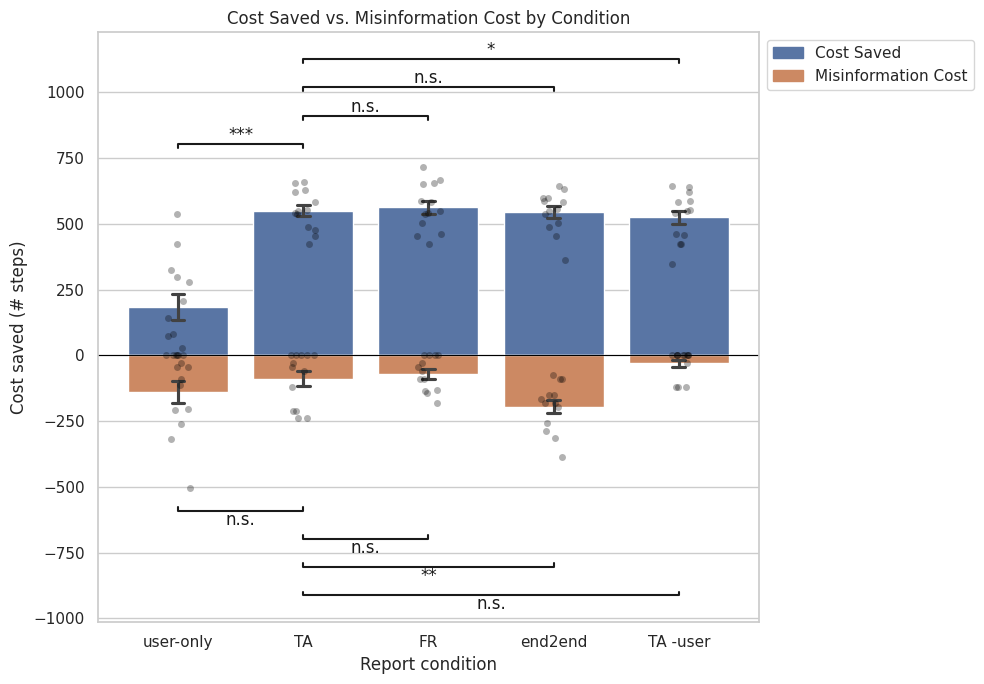

In [14]:
import matplotlib.patches as mpatches


sns.set_theme(style="whitegrid")
df["inverse_misinfo_cost"] = df["iac_misinformation_cost"] * -1
conditions_to_plot = ["user-only", "TA", "FR", "end2end", "TA -user"]
plot_df = df[df['condition'].isin(conditions_to_plot)]
# metrics_to_plot = ["iac_cost_saved", "iac_misinformation_cost"]

fig, ax = plt.subplots(figsize=(10, 7))
# fig, ax = plt.subplots()
x = list(range(len(conditions_to_plot)))
width = 0.35

sns.barplot(data=plot_df, x='condition', y="iac_cost_saved", ax=ax, capsize=.1, errorbar='se', 
                order=conditions_to_plot,
                # color="#6929c4"
                )
sns.stripplot(data=plot_df, x='condition', y="iac_cost_saved", ax=ax, color='black', alpha=0.3,
                order=conditions_to_plot)
    
sns.barplot(data=plot_df, x='condition', y="inverse_misinfo_cost", ax=ax, capsize=.1, errorbar='se', 
                order=conditions_to_plot,
                # color="#1192e8"
                )
sns.stripplot(data=plot_df, x='condition', y="inverse_misinfo_cost", ax=ax, color='black', alpha=0.3,
                order=conditions_to_plot)
    

# # Add post-hoc significance markers if available
idx_map = {c: idx for idx, c in enumerate(conditions_to_plot)}

# for positive (cost_saved)
metric = "iac_cost_saved"
metric_posthoc = posthoc_df[posthoc_df['Metric'] == metric]

max_y = plot_df[metric].max()
y_offset = max_y * 0.1
curr_y = max_y + y_offset

for _, row in metric_posthoc.iterrows():
    p_adj = row['p-adj']
    p1_name, p2_name = row['Comparison'].split(' vs ')
    if p1_name in conditions_to_plot and p2_name in conditions_to_plot:
        annotate_stats(ax, p_adj, idx_map[p1_name], idx_map[p2_name], curr_y, y_offset*0.2)
        curr_y += (y_offset * 1.5)

# for negative (misinfo cost)
metric = "iac_misinformation_cost"
metric_posthoc = posthoc_df[posthoc_df['Metric'] == metric]
max_y = plot_df[metric].max()
# y_offset = max_y * 0.1
curr_y = max_y * -1 - y_offset
for _, row in metric_posthoc.iterrows():
    p_adj = row['p-adj']
    p1_name, p2_name = row['Comparison'].split(' vs ')
    if p1_name in conditions_to_plot and p2_name in conditions_to_plot:
        annotate_stats_inverted(ax, p_adj, idx_map[p1_name], idx_map[p2_name], curr_y, y_offset*0.2)
        curr_y -= (y_offset * 1.5)


ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Cost saved (# steps)")
ax.set_xlabel("Report condition")
ax.set_title("Cost Saved vs. Misinformation Cost by Condition")
# ax.legend()
# Grab the colors seaborn assigned to each set of bars
cost_saved_color = ax.patches[0].get_facecolor()
misinfo_color = ax.patches[len(conditions_to_plot)].get_facecolor()

cost_saved_patch = mpatches.Patch(color=cost_saved_color, label='Cost Saved')
misinfo_patch = mpatches.Patch(color=misinfo_color, label='Misinformation Cost')

ax.legend(handles=[cost_saved_patch, misinfo_patch], bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

## 5. Descriptives: Content categorization of user-onlys


In [15]:
CATEGORY_CSV = "/media/kaleb/T7/handover_project/participant_data/analysis/content_categorization/aggregated_content_categorization.csv"

content_df = pd.read_csv(CATEGORY_CSV)
content_df = content_df.set_index("participant_id")

content_props = content_df.copy()
content_props["total tokens"] = content_props.sum(axis=1)
content_props = content_props.drop(
                    columns=["total tokens"]
                ).div(
                    content_props["total tokens"], axis=0
                )

content_props

,state,knowledge,ambiguous,meta
participant_id,,,,
501,0.326241,0.609929,0.063830,0.000000
502,0.500000,0.161765,0.338235,0.000000
503,0.770492,0.229508,0.000000,0.000000
504,0.771739,0.000000,0.000000,0.228261
505,0.382609,0.617391,0.000000,0.000000
506,0.780645,0.219355,0.000000,0.000000
507,0.418367,0.500000,0.000000,0.081633
508,0.480447,0.519553,0.000000,0.000000
509,0.494774,0.351916,0.128920,0.024390


In [16]:
# Calculate descriptive statistics (mean, median, range, std) of the percent of each content type relative to total token count
content_pcts = content_props * 100
descriptive_stats = pd.DataFrame({
    'mean': content_pcts.mean(),
    'median': content_pcts.median(),
    'minimum': content_pcts.min(),
    'maximum': content_pcts.max(),
    'std': content_pcts.std()
}).T
descriptive_stats

,state,knowledge,ambiguous,meta
mean,54.889272,35.324774,6.563340,3.222614
median,50.000000,35.191638,0.000000,0.000000
minimum,17.989418,0.000000,0.000000,0.000000
maximum,78.064516,66.137566,33.823529,22.826087
std,19.494296,21.491589,11.036867,6.647533


### Summary of Content Category Descriptives (Percentages)

The descriptive statistics for each content category (expressed as percentages of the total token count) reveal the following patterns across participant reports:
- **State** tokens represent the majority of the content, with a mean of **54.89%** (median = 50.00%, SD = 19.49%).
- **Knowledge** tokens are the second most common type, comprising a mean of **35.32%** (median = 35.19%, SD = 21.49%).
- **Ambiguous** (mean = 6.56%, median = 0.00%, SD = 11.04%) and **Meta** (mean = 3.22%, median = 0.00%, SD = 6.65%) tokens are much less frequent and are absent in many participant reports.

We also note substantial individual variation across participants, particularly in the proportions of state (range = 60.08%) and knowledge (range = 66.14%) tokens.

<Axes: title={'center': 'Content makeup in user-onlys by category'}, xlabel='content label', ylabel='proportion of tokens in report'>

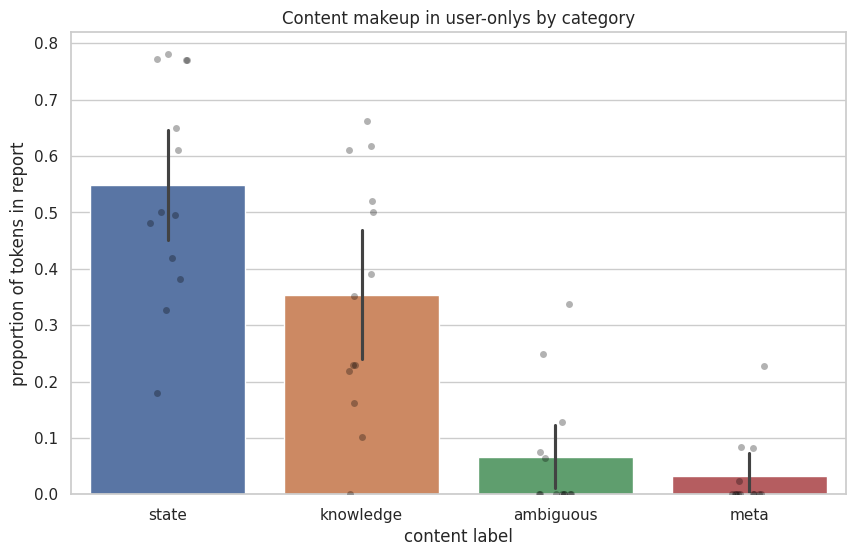

In [17]:
ax = sns.barplot(data=content_props)
ax.set_xlabel("content label")
ax.set_ylabel("proportion of tokens in report")
ax.set_title("Content makeup in user-onlys by category")
sns.stripplot(data=content_props, ax=ax, color='black', alpha=0.3)

Text(0.5, 1.0, 'Content makeup in user-onlys by user')

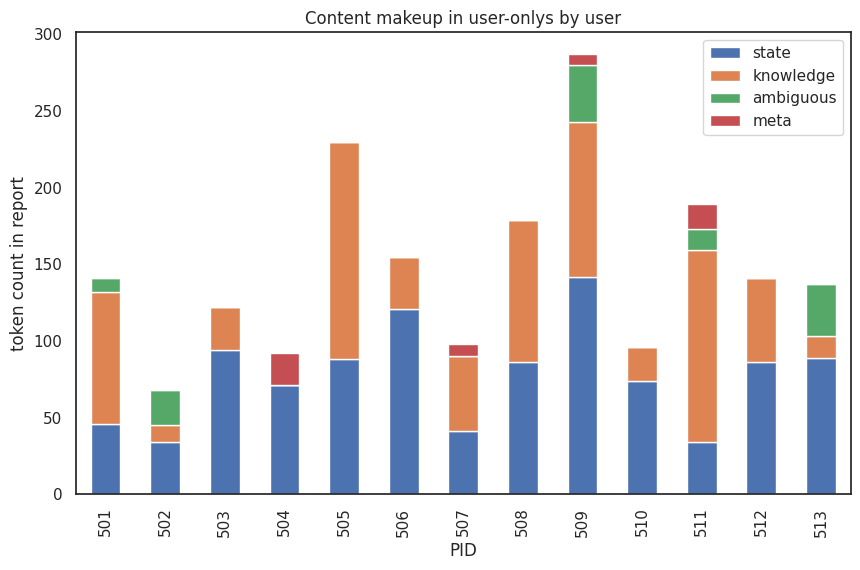

In [18]:
sns.set(style="white")
ax = content_df.plot(kind="bar", stacked=True)
ax.set_xlabel("PID")
ax.set_ylabel("token count in report")
ax.set_title("Content makeup in user-onlys by user")

## 6. Correlation Analysis: Content Makeup vs. Performance

We examine the correlations within participant reports (the `user-only` condition) to explore the relationship between communicative content and performance metrics:
1. **State-Categorized Tokens vs. IAC Cost Saved**: Correlation between the absolute token count of specifically state-categorized clauses and the Information Access Cost (IAC) cost saved.
2. **State:Knowledge Token Ratio vs. Soft Recall**: Correlation between the ratio of state to knowledge tokens and the soft recall scores.

We compute Pearson and Spearman correlation coefficients and plot the relationships.

State Tokens vs. IAC Cost Saved:
  Pearson correlation: r = 0.1697, p = 0.5793
  Spearman correlation: rho = 0.4072, p = 0.1673

State:Knowledge Ratio vs. Soft Recall:
  Pearson correlation: r = -0.2063, p = 0.4990
  Spearman correlation: rho = -0.0443, p = 0.8858


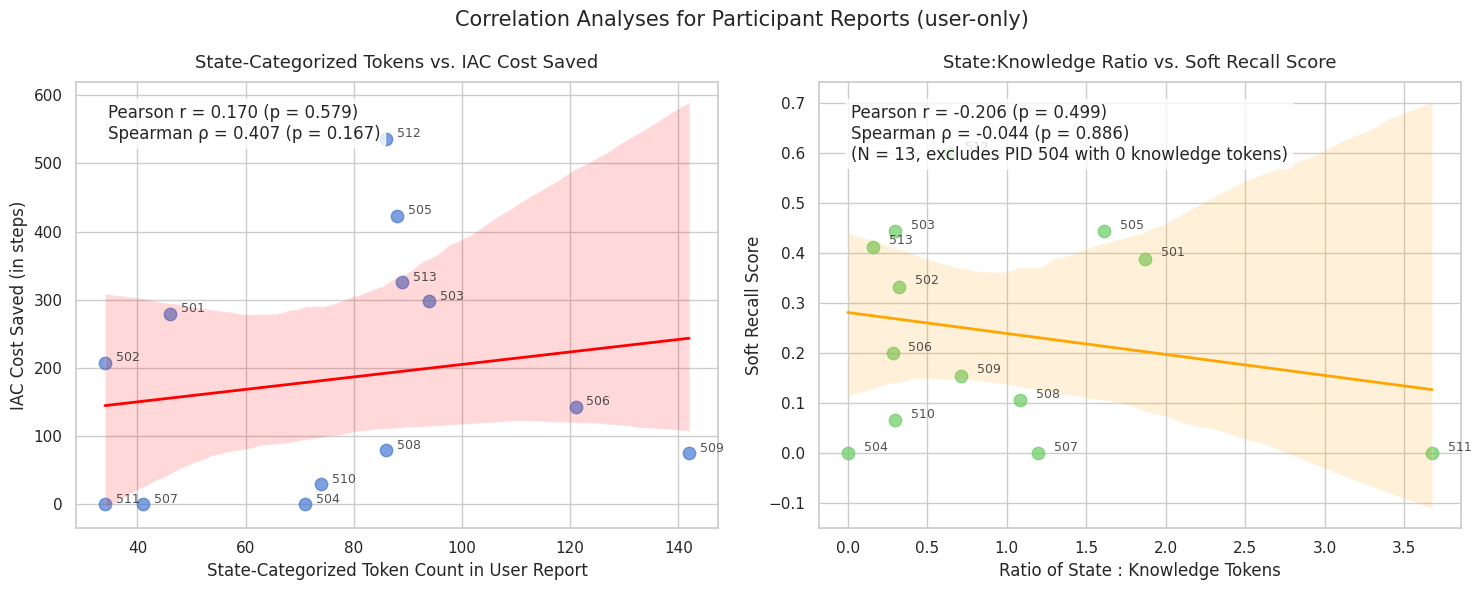

In [19]:
# Ensure participant_id indices are of the same type (string) for clean merging
df_wide.index = df_wide.index.astype(str)
content_df.index = content_df.index.astype(str)

# Create merged dataframe
merged_df = pd.DataFrame({
    'state_tokens': content_df['state'],
    'knowledge_tokens': content_df['knowledge'],
    'iac_cost_saved': df_wide[('iac_cost_saved', 'user-only')],
    'soft_recall': df_wide[('soft_recall', 'user-only')]
})

# Calculate state:knowledge ratio (handling division by zero by converting inf to NaN)
# merged_df['state_knowledge_ratio'] = merged_df['state_tokens'] / merged_df['knowledge_tokens']
merged_df['state_knowledge_ratio'] = merged_df['knowledge_tokens'] / merged_df['state_tokens']
merged_df_clean = merged_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['state_knowledge_ratio', 'soft_recall'])

# Calculate correlations
pearson_r1, pearson_p1 = stats.pearsonr(merged_df['state_tokens'], merged_df['iac_cost_saved'])
spearman_r1, spearman_p1 = stats.spearmanr(merged_df['state_tokens'], merged_df['iac_cost_saved'])

pearson_r2, pearson_p2 = stats.pearsonr(merged_df_clean['state_knowledge_ratio'], merged_df_clean['soft_recall'])
spearman_r2, spearman_p2 = stats.spearmanr(merged_df_clean['state_knowledge_ratio'], merged_df_clean['soft_recall'])

print(f"State Tokens vs. IAC Cost Saved:")
print(f"  Pearson correlation: r = {pearson_r1:.4f}, p = {pearson_p1:.4f}")
print(f"  Spearman correlation: rho = {spearman_r1:.4f}, p = {spearman_p1:.4f}")
print(f"\nState:Knowledge Ratio vs. Soft Recall:")
print(f"  Pearson correlation: r = {pearson_r2:.4f}, p = {pearson_p2:.4f}")
print(f"  Spearman correlation: rho = {spearman_r2:.4f}, p = {spearman_p2:.4f}")

# Plotting
sns.set_theme(style='whitegrid', palette='muted')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Left plot: State Tokens vs. IAC Cost Saved
sns.regplot(data=merged_df, x='state_tokens', y='iac_cost_saved', ax=ax1,
            scatter_kws={'s': 80, 'alpha': 0.7, 'color': 'b'}, 
            line_kws={'color': 'red', 'linewidth': 2})
for pid in merged_df.index:
    ax1.text(merged_df.loc[pid, 'state_tokens'] + 2, 
             merged_df.loc[pid, 'iac_cost_saved'] + 2, 
             str(pid), fontsize=9, alpha=0.8)
ax1.set_xlabel('State-Categorized Token Count in User Report', fontsize=12)
ax1.set_ylabel('IAC Cost Saved (in steps)', fontsize=12)
ax1.set_title('State-Categorized Tokens vs. IAC Cost Saved', fontsize=13, pad=10)
ax1.text(0.05, 0.95, f'Pearson r = {pearson_r1:.3f} (p = {pearson_p1:.3f})\nSpearman ρ = {spearman_r1:.3f} (p = {spearman_p1:.3f})',
         transform=ax1.transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Right plot: State:Knowledge Ratio vs. Soft Recall
sns.regplot(data=merged_df_clean, x='state_knowledge_ratio', y='soft_recall', ax=ax2,
            scatter_kws={'s': 80, 'alpha': 0.7, 'color': 'g'}, 
            line_kws={'color': 'orange', 'linewidth': 2})
for pid in merged_df_clean.index:
    ax2.text(merged_df_clean.loc[pid, 'state_knowledge_ratio'] + 0.1, 
             merged_df_clean.loc[pid, 'soft_recall'] + 0.005, 
             str(pid), fontsize=9, alpha=0.8)
ax2.set_xlabel('Ratio of State : Knowledge Tokens', fontsize=12)
ax2.set_ylabel('Soft Recall Score', fontsize=12)
ax2.set_title('State:Knowledge Ratio vs. Soft Recall Score', fontsize=13, pad=10)
ax2.text(0.05, 0.95, f'Pearson r = {pearson_r2:.3f} (p = {pearson_p2:.3f})\nSpearman ρ = {spearman_r2:.3f} (p = {spearman_p2:.3f})\n(N = {len(merged_df_clean)}, excludes PID 504 with 0 knowledge tokens)',
         transform=ax2.transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Correlation Analyses for Participant Reports (user-only)', fontsize=15, y=0.98)
plt.tight_layout()
plt.show()

notes from meeting with brad
- partial credit wherever possible 
    - manually inspect main generation pipeline
    - manually inspect/redo/verify content classification
- framing/narrative is good, can move forward with writing
